In [26]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import PIL
import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras


In [27]:
dataset=tf.keras.preprocessing.image_dataset_from_directory(
    "colored_images",
    shuffle=True,
    image_size=(256,256),
    batch_size=32
)


Found 3662 files belonging to 5 classes.


In [28]:
# 1. Determine the total number of batches
total_batches = len(dataset)

# 2. Define split sizes (e.g., 80% Train, 10% Val, 10% Test)
train_size = int(0.75 * total_batches)
val_size = int(0.05 * total_batches)
test_size = int(0.2 * total_batches)

# 3. Split the dataset
dataset_train = dataset.take(train_size)
dataset_val = dataset.skip(train_size).take(val_size)
dataset_test = dataset.skip(train_size + val_size).take(test_size)

print(f"Train batches: {len(dataset_train)}")
print(f"Validation batches: {len(dataset_val)}")
print(f"Test batches: {len(dataset_test)}")

Train batches: 86
Validation batches: 5
Test batches: 23


In [29]:
class_names=dataset.class_names
class_names

['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

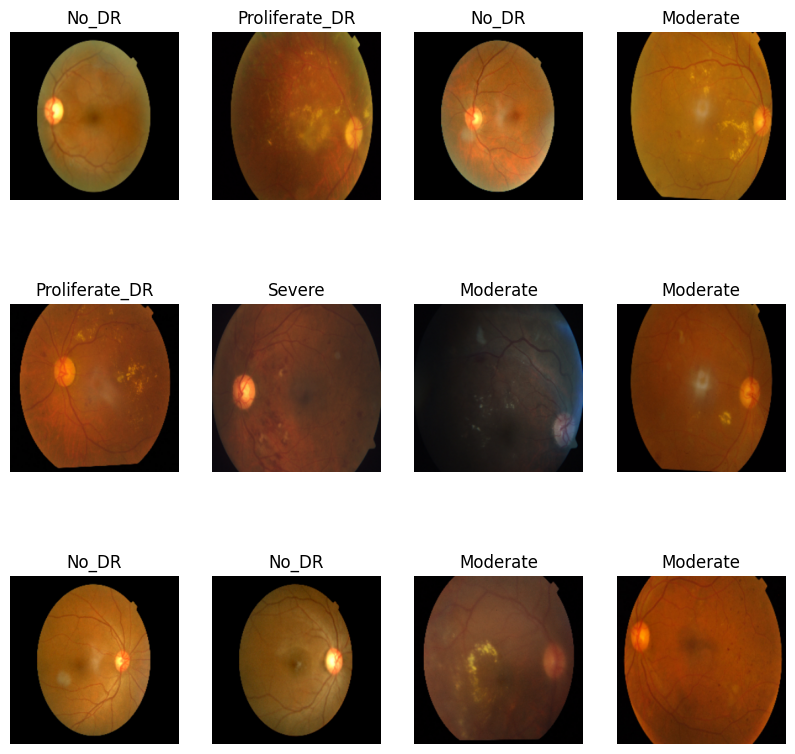

In [30]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset_train.take(1):
    for i in range(12):
        ax=plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

In [31]:
dataset_train = dataset_train.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
dataset_val = dataset_val.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
dataset_test = dataset_test.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [32]:
resize_and_rescale = tf.keras.Sequential([
  tf.keras.layers.Resizing(256,256),
  tf.keras.layers.Rescaling(1./255),
])

In [33]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
])

In [34]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50

In [35]:
dataset_train = dataset_train.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [36]:
from keras import models
from keras import layers

In [37]:
# Create base model using Keras applications
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,  # Remove the top classification layer
    weights='imagenet',
    pooling='avg'  # Add global average pooling
)
base_model.trainable = False

# Now use this in your Sequential model
n_classes=5
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    resize_and_rescale,
    base_model,
    tf.keras.layers.Dense(n_classes, activation='softmax'),
])

C:\Users\puska\AppData\Local\Temp\ipykernel_31656\1405166556.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [38]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Just the string name
    metrics=['accuracy']
)

In [40]:
history = model.fit(
    dataset_train,
    batch_size=BATCH_SIZE,
    validation_data=dataset_val,
    verbose=1,
    epochs=5,
)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 76s 776ms/step - accuracy: 0.6472 - loss: 1.0126 - val_accuracy: 0.6938 - val_loss: 0.8320
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 758ms/step - accuracy: 0.7304 - loss: 0.7454 - val_accuracy: 0.7188 - val_loss: 0.7534
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 741ms/step - accuracy: 0.7496 - loss: 0.7034 - val_accuracy: 0.7000 - val_loss: 0.7637
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 755ms/step - accuracy: 0.7594 - loss: 0.6667 - val_accuracy: 0.7375 - val_loss: 0.6888
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 65s 747ms/step - accuracy: 0.7616 - loss: 0.6491 - val_accuracy: 0.7500 - val_loss: 0.6680


first image to predict
actual label: No_DR
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
predicted label: No_DR


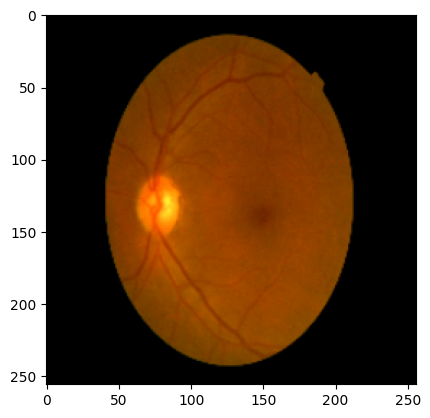

In [41]:
for images_batch, labels_batch in dataset_test.take(1):
    
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [42]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [43]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


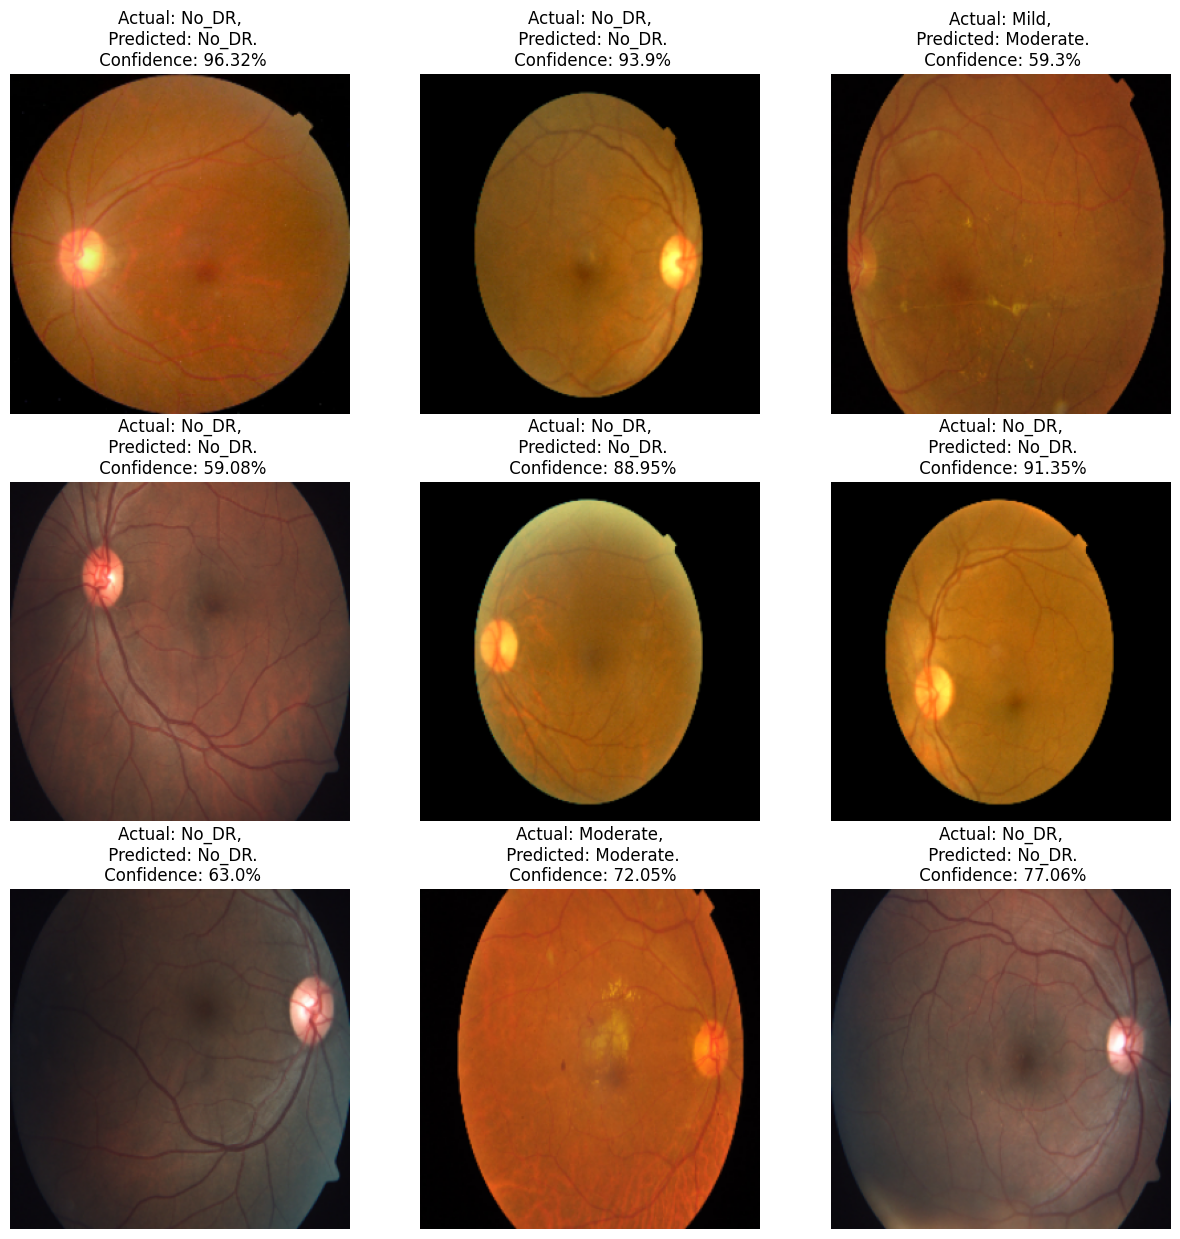

In [44]:
plt.figure(figsize=(15, 15))
for images, labels in dataset_test.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]] 
        
        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
        
        plt.axis("off")

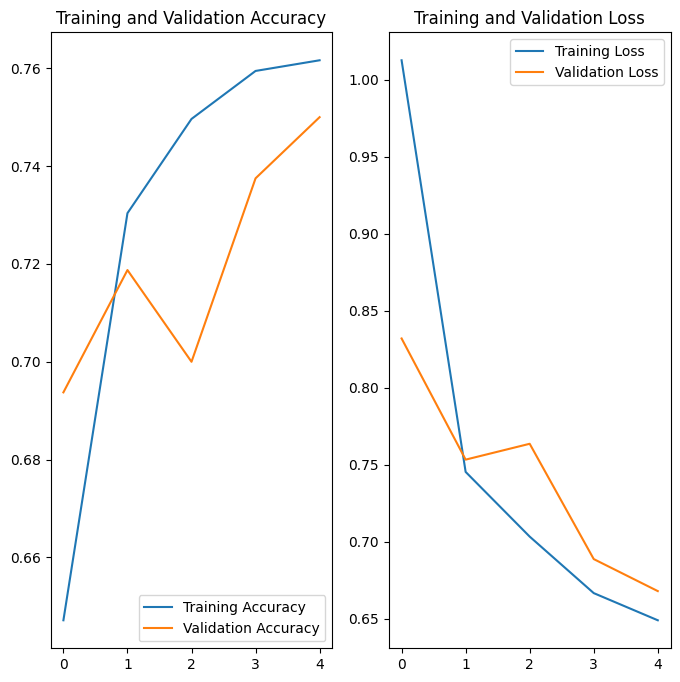

In [45]:
EPOCHS=5
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [48]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Initialize lists to store data
y_true = []
y_pred_classes = []  # Integer class labels (0, 1, 2...) for Confusion Matrix
y_prob = []          # Full probability matrix for ROC AUC

print(f"Predicting on {len(dataset_test)} batches...")

# 2. Run prediction loop ONCE
for images, labels in dataset_test:
    # Get the raw probabilities (Shape: batch_size x 5)
    batch_probs = model.predict(images, verbose=0)
    
    # Get the integer class prediction (highest probability)
    batch_preds = np.argmax(batch_probs, axis=1)
    
    # Store them
    y_true.extend(labels.numpy())
    y_pred_classes.extend(batch_preds)
    y_prob.extend(batch_probs) # IMPORTANT: Keep the full [N, 5] matrix!

# 3. Convert to Numpy Arrays for Scikit-Learn
y_true = np.array(y_true)
y_pred_classes = np.array(y_pred_classes)
y_prob = np.array(y_prob)

# --- REPORTING ---

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

# ROC-AUC (Multiclass)
# We pass y_prob (the full 5-column matrix), NOT y_prob[:, 1]
try:
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    print(f"ROC AUC (One-vs-Rest): {roc_auc:.4f}")
except ValueError as e:
    print(f"ROC AUC Error: {e}")

Predicting on 23 batches...

Classification Report:
                precision    recall  f1-score   support

          Mild       0.50      0.32      0.39        76
      Moderate       0.60      0.73      0.66       206
         No_DR       0.93      0.95      0.94       368
Proliferate_DR       0.35      0.31      0.33        49
        Severe       0.12      0.05      0.07        37

      accuracy                           0.74       736
     macro avg       0.50      0.47      0.48       736
  weighted avg       0.71      0.74      0.72       736

Confusion Matrix:
[[ 24  41   8   3   0]
 [ 14 150  13  19  10]
 [  7   9 351   0   1]
 [  1  28   1  15   4]
 [  2  22   5   6   2]]
ROC AUC (One-vs-Rest): 0.8867


In [50]:
# The modern, recommended way
model.save('diabetic_retinopathy_model.keras')

print("Model saved successfully in the new Keras format!")

Model saved successfully in the new Keras format!
